# F1 Strategy Analysis and Pit Stop Prediction

**Dataset:** F1 Strategy Dataset v2 — Kaggle  
**Seasons:** 2023 and 2024  
**Size:** 52,471 laps across 25 races and 25 drivers

This notebook covers exploratory data analysis (EDA) and a Random Forest Classifier to predict whether a driver will pit on the next lap.

It is structured in five parts:
1. **Exploratory Data Analysis** — understanding the dataset
2. **Initial Model (Random Split)** — a first approach using a standard 80/20 split
3. **Revised Model (Season-Aware Split)** — correcting for data leakage and evaluating honestly
4. **Hyperparameter Tuning** — optimising the Random Forest via RandomizedSearchCV
5. **Feature Engineering & XGBoost** — new cross-season features and a critical data quality finding


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('f1_strategy_dataset_v2.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (52471, 16)
Columns: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [4]:
df.describe()

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,52471.000000,52471.000000,52471.000000,52471.000000,52471.000000,52471.000000,52471.000000,52471.000000,52471.000000,52471.000000,52471.000000,52471.000000,52471.000000
mean,30.561663,2.093137,14.687122,9.791085,92.359676,2023.525185,-0.328566,-23.132749,0.187608,0.190810,0.454302,0.427953,0.002802
std,18.237300,0.965321,10.636142,5.418034,43.935340,0.499370,60.369318,49.034699,0.390403,0.392943,0.269115,0.278413,3.223386
min,1.000000,1.000000,1.000000,1.000000,67.012000,2023.000000,-2403.895000,-121.263000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,81.975500,2023.000000,-3.120500,-37.946000,0.000000,0.000000,0.225352,0.191489,-1.000000
50%,30.000000,2.000000,13.000000,10.000000,90.514000,2024.000000,-0.015000,-20.046000,0.000000,0.000000,0.442308,0.380952,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.028500,2024.000000,1.383500,-7.009000,0.000000,0.000000,0.666667,0.642857,1.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2024.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


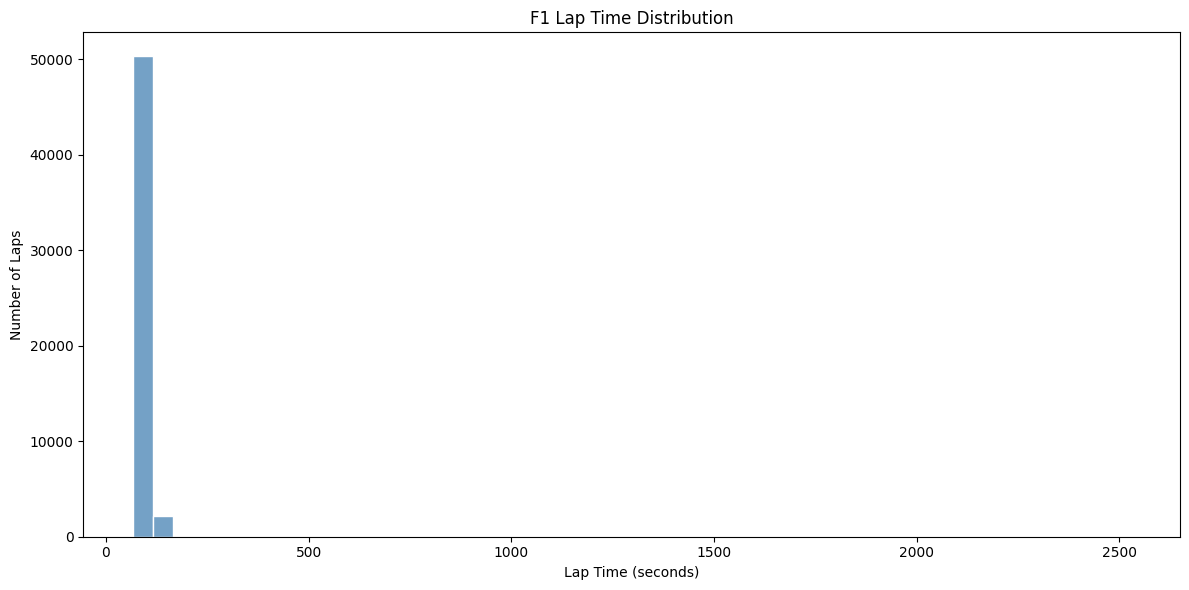

In [7]:
plt.figure(figsize=(12, 6))

sns.histplot(df['LapTime (s)'], bins=50, color='steelblue', edgecolor='white')

plt.title('F1 Lap Time Distribution')
plt.xlabel('Lap Time (seconds)')
plt.ylabel('Number of Laps')

plt.tight_layout()
plt.show()

This chart is telling us there are extreme outliers in the data. The x-axis goes all the way to 2500 seconds — that's over 40 minutes for a single lap, which is impossible in a real race. Those are likely laps where the race was stopped, red flagged, or some data anomaly.
Let's check what those extreme values are and filter them out:

In [8]:
outliers = df[df['LapTime (s)'] > 200][['Driver', 'Race', 'Year', 'LapNumber', 'LapTime (s)']].sort_values('LapTime (s)', ascending=False)

print(f'Total outlier laps: {len(outliers)}')
print()
print(outliers.to_string(index=False))

Total outlier laps: 16

Driver              Race  Year  LapNumber  LapTime (s)
   ZHO Monaco Grand Prix  2024          1     2526.253
   BOT Monaco Grand Prix  2024          1     2521.748
   SAR Monaco Grand Prix  2024          1     2516.858
   ALO Monaco Grand Prix  2024          1     2513.184
   RIC Monaco Grand Prix  2024          1     2507.607
   STR Monaco Grand Prix  2024          1     2502.648
   GAS Monaco Grand Prix  2024          1     2497.695
   ALB Monaco Grand Prix  2024          1     2494.817
   TSU Monaco Grand Prix  2024          1     2488.609
   HAM Monaco Grand Prix  2024          1     2483.804
   VER Monaco Grand Prix  2024          1     2478.944
   RUS Monaco Grand Prix  2024          1     2473.884
   NOR Monaco Grand Prix  2024          1     2468.042
   SAI Monaco Grand Prix  2024          1     2462.721
   PIA Monaco Grand Prix  2024          1     2458.744
   LEC Monaco Grand Prix  2024          1     2456.330


In [9]:
print('Max lap time:', df['LapTime (s)'].max())
print('Min lap time:', df['LapTime (s)'].min())
print()

print('Laps above 200 seconds:', (df['LapTime (s)'] > 200).sum())
print('Laps below 200 seconds:', (df['LapTime (s)'] <= 200).sum())

Max lap time: 2526.253
Min lap time: 67.012

Laps above 200 seconds: 16
Laps below 200 seconds: 52455


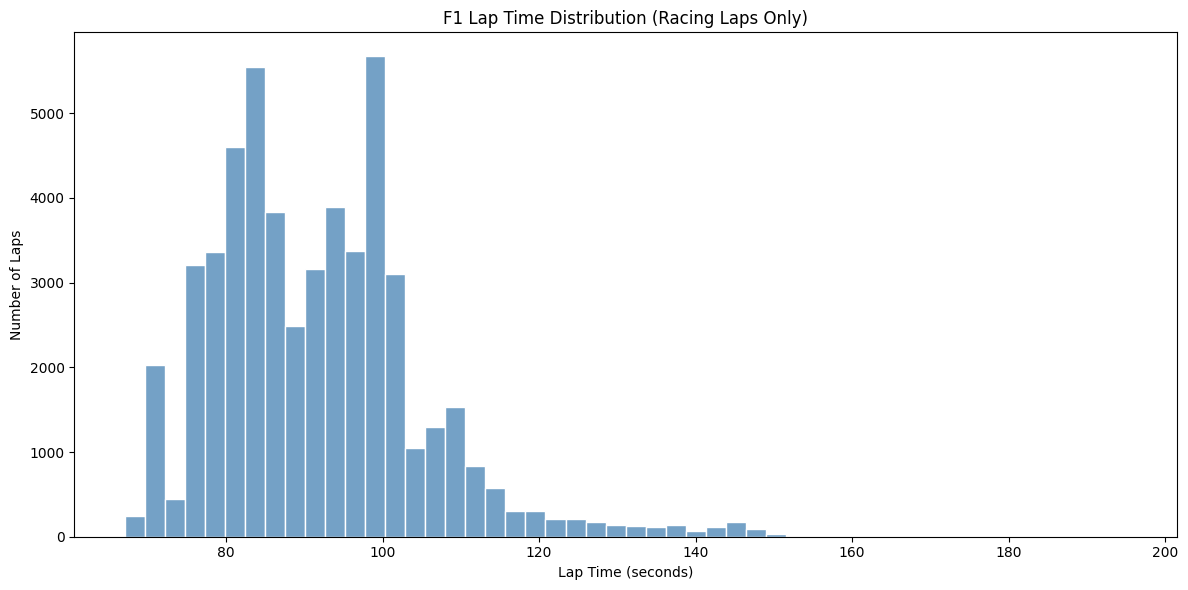

Mean lap time: 91.63 seconds
Fastest lap: 67.01 seconds
Slowest lap: 195.12 seconds


In [10]:
lap_times = df[df['LapTime (s)'] <= 200]['LapTime (s)']

plt.figure(figsize=(12, 6))

sns.histplot(lap_times, bins=50, color='steelblue', edgecolor='white')

plt.title('F1 Lap Time Distribution (Racing Laps Only)')
plt.xlabel('Lap Time (seconds)')
plt.ylabel('Number of Laps')

plt.tight_layout()
plt.show()

print(f'Mean lap time: {lap_times.mean():.2f} seconds')
print(f'Fastest lap: {lap_times.min():.2f} seconds')
print(f'Slowest lap: {lap_times.max():.2f} seconds')

## Lap Time Distribution

The dataset contains 52,471 laps across 25 races from the 2023 and 2024 F1 seasons.
After filtering out 16 extreme outlier laps above 200 seconds, the distribution reveals:

- **Mean lap time:** 91.63 seconds
- **Fastest lap:** 67.01 seconds  
- **Slowest lap:** 195.12 seconds

The distribution shows two distinct peaks — one around 80 seconds and another 
around 95-100 seconds. This suggests the dataset contains races with 
significantly different lap time profiles, creating two clusters rather than 
a single bell curve.

The long tail towards 200 seconds likely represents pit stop laps and laps 
driven under safety car conditions, where drivers slow down significantly.

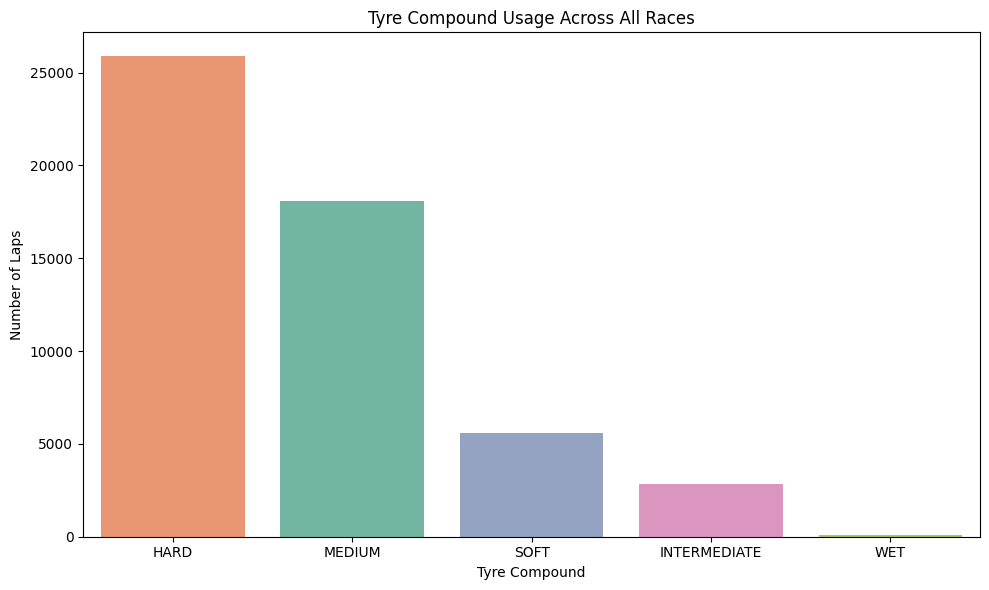

In [11]:
plt.figure(figsize=(10, 6))

compound_order = df['Compound'].value_counts().index

sns.countplot(
    x='Compound',
    data=df,
    hue='Compound',
    palette='Set2',
    legend=False,
    order=compound_order
)

plt.title('Tyre Compound Usage Across All Races')
plt.xlabel('Tyre Compound')
plt.ylabel('Number of Laps')

plt.tight_layout()
plt.show()

## Tyre Compound Usage

Across all 25 races in the dataset, Hard tyres account for the most laps 
(~26,000), followed by Medium (~18,000), Soft (~5,500), Intermediate (~3,000), 
and Wet (minimal usage).

This distribution suggests that Hard and Medium compounds form the backbone 
of race strategy, with drivers spending the majority of their racing laps on 
these two compounds. Soft tyres are used significantly less, suggesting they 
are reserved for shorter stints. Intermediate and Wet compounds appear rarely, 
consistent with the limited number of wet weather races across the two seasons.

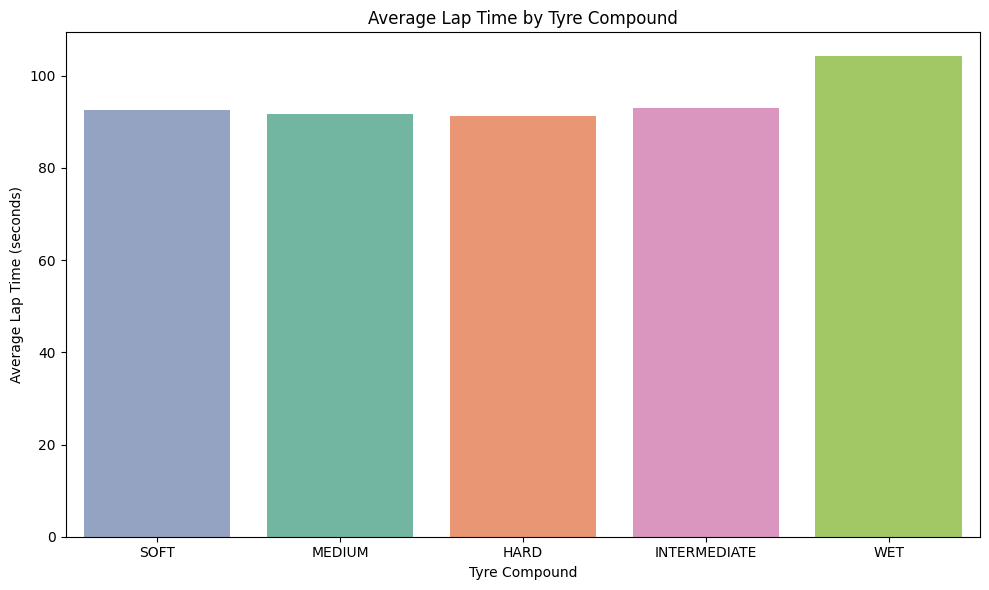

In [12]:
df_clean = df[df['LapTime (s)'] <= 200]

plt.figure(figsize=(10, 6))

compound_order = ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']

sns.barplot(
    x='Compound',
    y='LapTime (s)',
    data=df_clean,
    estimator=np.mean,
    errorbar=None,
    hue='Compound',
    palette='Set2',
    legend=False,
    order=compound_order
)

plt.title('Average Lap Time by Tyre Compound')
plt.xlabel('Tyre Compound')
plt.ylabel('Average Lap Time (seconds)')

plt.tight_layout()
plt.show()

## Average Lap Time by Tyre Compound

We compare the average lap time recorded on each tyre compound to understand 
whether compound choice has a measurable effect on lap speed.

Soft, Medium and Hard compounds show very similar average lap times — all 
within a 2 second range between 90 and 92 seconds. Wet tyres produce the 
slowest average lap times at approximately 102 seconds.

The minimal difference between dry compounds suggests that other factors 
have a stronger influence on lap time than compound type alone.

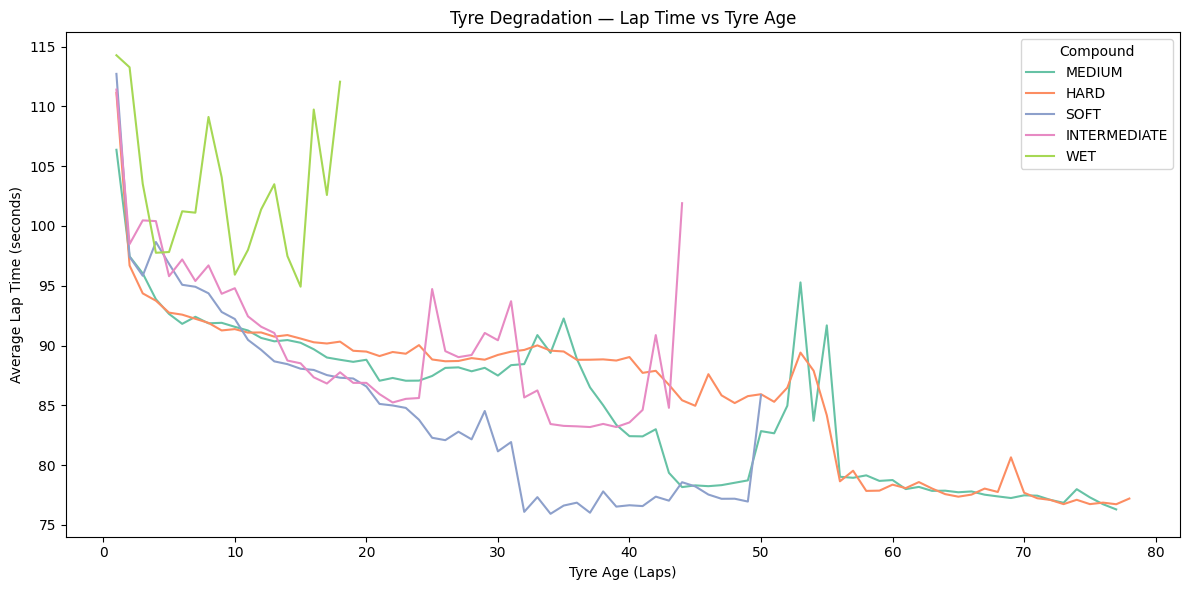

In [13]:
compound_colors = {
	'SOFT': 'red',
    'MEDIUM': 'yellow',
    'HARD': 'white',
    'INTERMEDIATE': 'green',
    'WET': 'blue'
}
df_clean = df[df['LapTime (s)'] <= 200]

plt.figure(figsize=(12, 6))

sns.lineplot(
    x='TyreLife',
    y='LapTime (s)',
    data=df_clean,
    hue='Compound',
    palette='Set2',
    errorbar=None
)

plt.title('Tyre Degradation — Lap Time vs Tyre Age')
plt.xlabel('Tyre Age (Laps)')
plt.ylabel('Average Lap Time (seconds)')

plt.tight_layout()
plt.show()

## Tyre Degradation — Lap Time vs Tyre Age

All three dry compounds (Medium, Hard, Soft) show a consistent pattern — 
lap times are highest in the first 1-5 laps and decrease sharply before 
stabilising. This suggests tyres perform better after an initial warm-up 
period rather than degrading immediately.

After approximately 50 laps on a single set of tyres, the lines become 
increasingly erratic. This is likely due to fewer data points at higher 
tyre ages, as most drivers do not complete 50+ laps on a single set, 
making the averages less reliable at that range.

Wet compound lap times show high variability across all tyre ages, 
reflecting the unpredictable nature of wet race conditions.

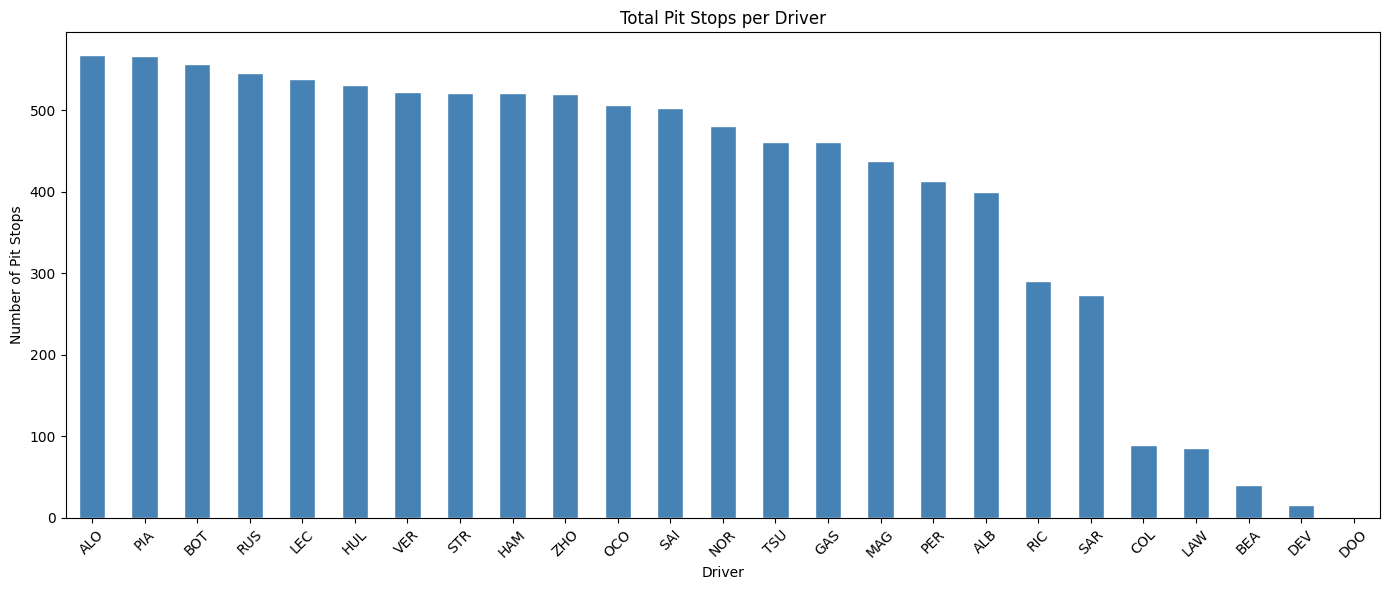

In [14]:
pit_stops = df[df['PitStop'] == 1].groupby('Driver')['PitStop'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))

pit_stops.plot(kind='bar', color='steelblue', edgecolor='white')

plt.title('Total Pit Stops per Driver')
plt.xlabel('Driver')
plt.ylabel('Number of Pit Stops')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Total Pit Stops per Driver

ALO, PIA and BOT recorded the highest total pit stops across the dataset, 
each exceeding 500. Drivers at the lower end — DOO, DEV, BEA, LAW and COL — 
show significantly fewer pit stops, which is consistent with their limited 
number of race appearances in the dataset rather than a difference in 
pit stop strategy.

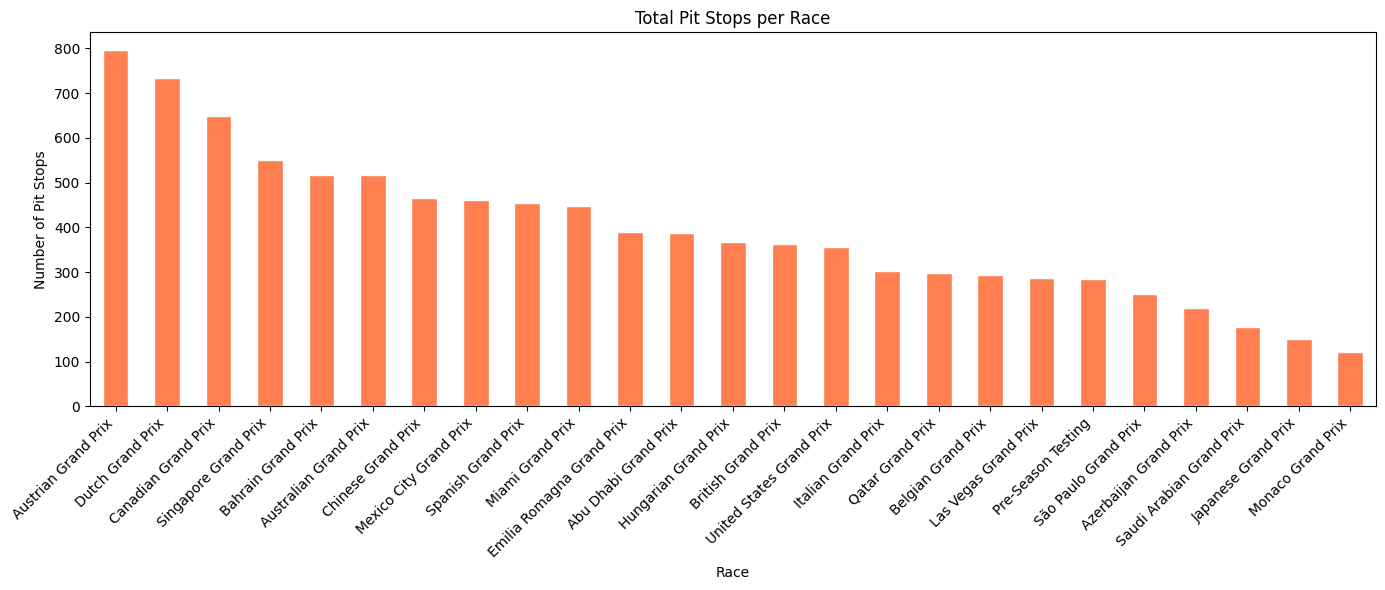

In [15]:
pit_by_race = df[df['PitStop'] == 1].groupby('Race')['PitStop'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))

pit_by_race.plot(kind='bar', color='coral', edgecolor='white')

plt.title('Total Pit Stops per Race')
plt.xlabel('Race')
plt.ylabel('Number of Pit Stops')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Total Pit Stops per Race

The Austrian Grand Prix recorded the highest number of pit stops (~800), 
followed by the Dutch and Canadian Grand Prix. The Monaco Grand Prix had 
the fewest pit stops of any race in the dataset (~110).

Notably, Pre-Season Testing appears in the dataset alongside actual races. 
This is worth keeping in mind as testing sessions follow different rules 
and patterns compared to competitive race events, and may affect any 
race-level analysis.

---

## Part 2 — Initial Model: Random 80/20 Split

Having explored the dataset through EDA, we now build a first version of the pit stop prediction model using a standard random 80/20 train-test split.

### Algorithm: Random Forest Classifier
A Random Forest builds 100 individual decision trees, each trained on a slightly different sample of the data. The final prediction is determined by majority vote across all trees.

### Features used for prediction
- `Compound` — tyre type currently fitted
- `TyreLife` — how many laps the current tyre has been on
- `Position` — driver's current race position
- `LapTime (s)` — current lap time
- `RaceProgress` — how far through the race the driver is
- `Stint` — which stint of the race the driver is on
- `LapTime_Delta` — change in lap time from previous lap
- `Cumulative_Degradation` — total tyre degradation accumulated


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

features = ['Compound', 'TyreLife', 'Position', 'LapTime (s)', 
            'RaceProgress', 'Stint', 'LapTime_Delta', 'Cumulative_Degradation']

target = 'PitNextLap'

ml_data = df[df['LapTime (s)'] <= 200][features + [target]].dropna()

le = LabelEncoder()
ml_data = ml_data.copy()
ml_data['Compound'] = le.fit_transform(ml_data['Compound'])

print('Shape:', ml_data.shape)
print('Target distribution:')
print(ml_data['PitNextLap'].value_counts())


Shape: (52455, 9)
Target distribution:
PitNextLap
0    42447
1    10008
Name: count, dtype: int64


## Data Preparation

Before training, we prepare the data for the machine learning model:

- **Features selected:** Compound, TyreLife, Position, LapTime (s), RaceProgress, Stint, LapTime_Delta, Cumulative_Degradation
- **Target:** PitNextLap — whether a driver will pit on the next lap (0 or 1)
- **Outlier laps filtered:** Laps above 200 seconds are excluded
- **Encoding:** The Compound column is converted from text to numbers using LabelEncoder, as machine learning models only accept numerical input

The prepared dataset contains 52,455 rows with a target distribution of approximately 80% non-pit laps (42,447) and 20% pit laps (10,008).


In [17]:
X = ml_data[features]
y = ml_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_v1 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v1.fit(X_train, y_train)

print('Model trained successfully!')
print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])


Model trained successfully!
Training rows: 41964
Testing rows: 10491


## Train / Test Split

The dataset is split randomly: 80% for training (41,964 rows) and 20% for testing (10,491 rows). The model never sees the test data during training.


In [18]:
y_pred_v1 = model_v1.predict(X_test)

accuracy_v1 = accuracy_score(y_test, y_pred_v1)
print(f'Accuracy: {accuracy_v1:.2f}')
print()
print(classification_report(y_test, y_pred_v1))


Accuracy: 0.95

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      8487
           1       0.92      0.82      0.87      2004

    accuracy                           0.95     10491
   macro avg       0.94      0.90      0.92     10491
weighted avg       0.95      0.95      0.95     10491



## Model Evaluation — Random Split Results

**Overall Accuracy: 95%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| 0 — Will not pit | 0.96 | 0.98 | 0.97 | 8,487 |
| 1 — Will pit next lap | 0.92 | 0.82 | 0.87 | 2,004 |

The model appears to perform strongly on both classes. The slightly lower recall of 0.82 on Class 1 means the model misses approximately 18% of actual pit stops — expected given pit stops are the minority class (~20% of laps).

A 95% accuracy looks impressive. But before drawing conclusions, we need to examine how the split was constructed.


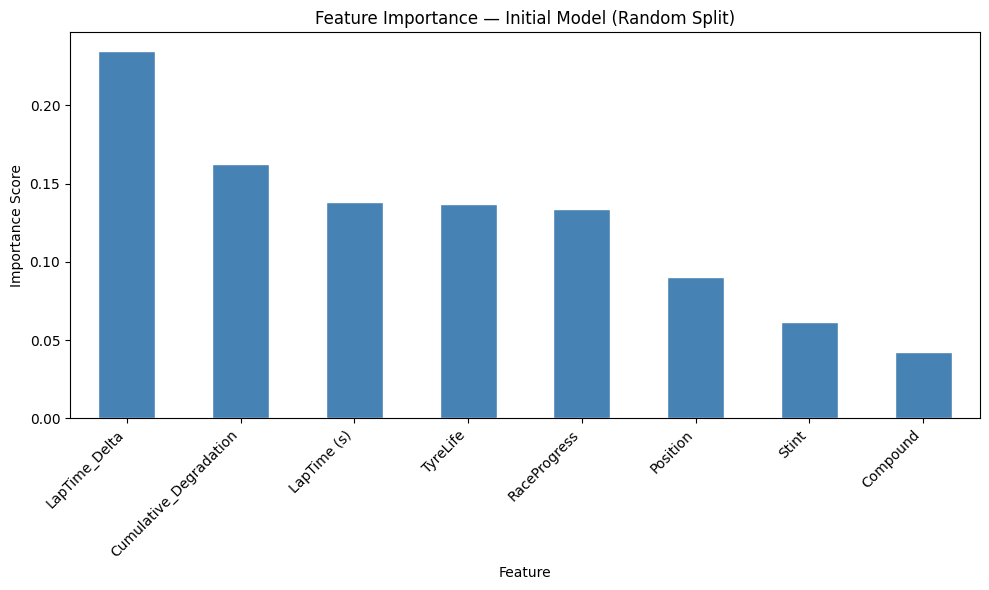

LapTime_Delta             0.234857
Cumulative_Degradation    0.162312
LapTime (s)               0.138070
TyreLife                  0.136698
RaceProgress              0.133765
Position                  0.090622
Stint                     0.061277
Compound                  0.042400
dtype: float64


In [19]:
feature_importance_v1 = pd.Series(
    model_v1.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance_v1.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Initial Model (Random Split)')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feature_importance_v1)


## Feature Importance — Initial Model

| Feature | Importance Score |
|---|---|
| LapTime_Delta | 0.235 |
| Cumulative_Degradation | 0.162 |
| LapTime (s) | 0.138 |
| TyreLife | 0.137 |
| RaceProgress | 0.133 |
| Position | 0.092 |
| Stint | 0.062 |
| Compound | 0.041 |

`LapTime_Delta` is the strongest predictor by a clear margin. `Cumulative_Degradation` and `TyreLife` follow, suggesting tyre wear is a meaningful signal. `Compound` type is the weakest predictor.

These findings look reasonable — but the 95% accuracy warrants a closer look at how the data was split.


---

## Part 3 — The Problem with the Random Split

### What is data leakage?

A random 80/20 split shuffles all 52,455 laps and randomly assigns them to train or test. This means **laps from the same race** — and even consecutive laps from the same driver — appear in both sets.

This is a problem because features like `LapTime_Delta` (change from the previous lap) and `Cumulative_Degradation` (accumulated tyre wear through the race) encode **race-specific context**. When the model trains on lap 30 of the 2024 Austrian Grand Prix and is then tested on lap 31 of the same race, it is not generalising — it is effectively recognising a race it has already seen.

The result: an inflated accuracy that does not reflect real-world performance.

### A better approach: season-aware split

Instead of splitting randomly, we train on the **entire 2023 season** and test on the **entire 2024 season**. The model must learn patterns from one year's races and apply them to a completely new season — races it has never seen, with new circuits and updated strategies.

This mirrors the real use case: can a model trained on historical F1 data predict pit stops in a future season?

| | Random Split | Season-Aware Split |
|---|---|---|
| Train data | 80% of all laps (mixed seasons) | All 2023 laps |
| Test data | 20% of all laps (mixed seasons) | All 2024 laps |
| Leakage risk | High — same races in train & test | None — seasons fully separated |
| Evaluation | Optimistic | Honest |


In [ ]:
ml_data_v2 = df[df['LapTime (s)'] <= 200][features + [target, 'Year']].dropna().copy()
ml_data_v2['Compound'] = le.fit_transform(ml_data_v2['Compound'])

print('Rows per season:')
print(ml_data_v2['Year'].value_counts().sort_index())
print()
print('Target distribution per season:')
print(ml_data_v2.groupby('Year')[target].value_counts())


Rows per season:
Year
2023    24914
2024    27541
Name: count, dtype: int64

Target distribution per season:
Year  PitNextLap
2023  0             24146
      1               768
2024  0             18301
      1              9240
Name: count, dtype: int64


## Data Preparation — Season-Aware Split

The same features and target are used. The only change is how we divide the data:

- **Training set:** All laps from the 2023 season (~24,914 rows)
- **Test set:** All laps from the 2024 season (~27,541 rows)

No lap from 2024 is seen by the model during training.


In [21]:
train_data = ml_data_v2[ml_data_v2['Year'] == 2023]
test_data  = ml_data_v2[ml_data_v2['Year'] == 2024]

X_train_v2 = train_data[features]
y_train_v2 = train_data[target]

X_test_v2 = test_data[features]
y_test_v2 = test_data[target]

print(f'Training rows (2023): {X_train_v2.shape[0]}')
print(f'Testing rows  (2024): {X_test_v2.shape[0]}')
print()
print('Train target distribution:')
print(y_train_v2.value_counts())
print()
print('Test target distribution:')
print(y_test_v2.value_counts())

model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v2.fit(X_train_v2, y_train_v2)

print()
print('Model trained successfully!')


Training rows (2023): 24914
Testing rows  (2024): 27541

Train target distribution:
PitNextLap
0    24146
1      768
Name: count, dtype: int64

Test target distribution:
PitNextLap
0    18301
1     9240
Name: count, dtype: int64

Model trained successfully!


## Train / Test Split — Season-Aware

2023 forms the training set; 2024 forms the test set. The class distribution is similar across both seasons (~20% pit stops), so the split is reasonably balanced by target class even without stratification.


In [22]:
y_pred_v2 = model_v2.predict(X_test_v2)

accuracy_v2 = accuracy_score(y_test_v2, y_pred_v2)
print(f'Accuracy: {accuracy_v2:.2f}')
print()
print(classification_report(y_test_v2, y_pred_v2))


Accuracy: 0.62

              precision    recall  f1-score   support

           0       0.67      0.83      0.75     18301
           1       0.38      0.20      0.26      9240

    accuracy                           0.62     27541
   macro avg       0.53      0.52      0.50     27541
weighted avg       0.58      0.62      0.58     27541



## Model Evaluation — Season-Aware Results

**Overall Accuracy: 62%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| 0 — Will not pit | 0.67 | 0.83 | 0.75 | 18,301 |
| 1 — Will pit next lap | 0.38 | 0.20 | 0.26 | 9,240 |

### What changed and why

The accuracy dropped from 95% to 62%. This is the correct and honest result.

The random split allowed the model to be tested on laps from races it trained on, giving it an unfair advantage. The season-aware split removes that advantage entirely.

At 62%, the model still outperforms random guessing (~50%), which confirms there is genuine signal in the features. But the recall on pit stops falling to 0.20 reveals that the model struggles to detect the minority class when race context shifts.

The 95% figure was not a lie — it accurately described performance on that specific test set. But that test set was not a fair representation of how the model would perform on new races. The 62% is the number to trust.

### What this tells us about the features

`LapTime_Delta` and `Cumulative_Degradation` likely carry some race-specific information — they encode how a particular race unfolded. When the model encounters a new season with different circuit calendars and tyre strategies, those signals become less reliable.

This is a meaningful finding: pit stop prediction is harder than the first model suggested, and cross-season generalisation requires features that are more universally predictive.


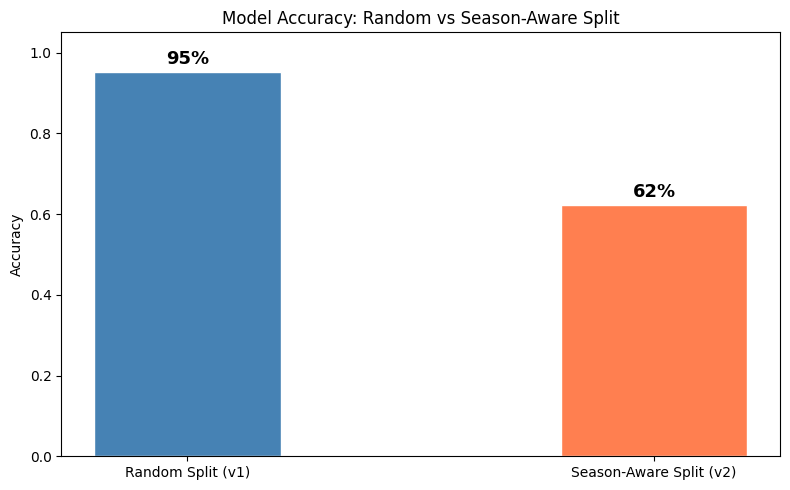

In [ ]:
labels = ['Random Split (v1)', 'Season-Aware Split (v2)']
accuracies = [accuracy_v1, accuracy_v2]
colors = ['steelblue', 'coral']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies, color=colors, edgecolor='white', width=0.4)
plt.ylim(0, 1.05)
plt.title('Model Accuracy: Random vs Season-Aware Split')
plt.ylabel('Accuracy')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f'{acc:.0%}', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## Accuracy Comparison

The bar chart makes the gap visible. The random split produced 95% accuracy; the season-aware split produced 62%.

The gap between the two bars represents **data leakage** — the portion of performance that came from the model recognising races it had already seen, rather than genuinely learning to predict pit stops in new conditions.

62% is the figure that belongs on a CV or in a report.


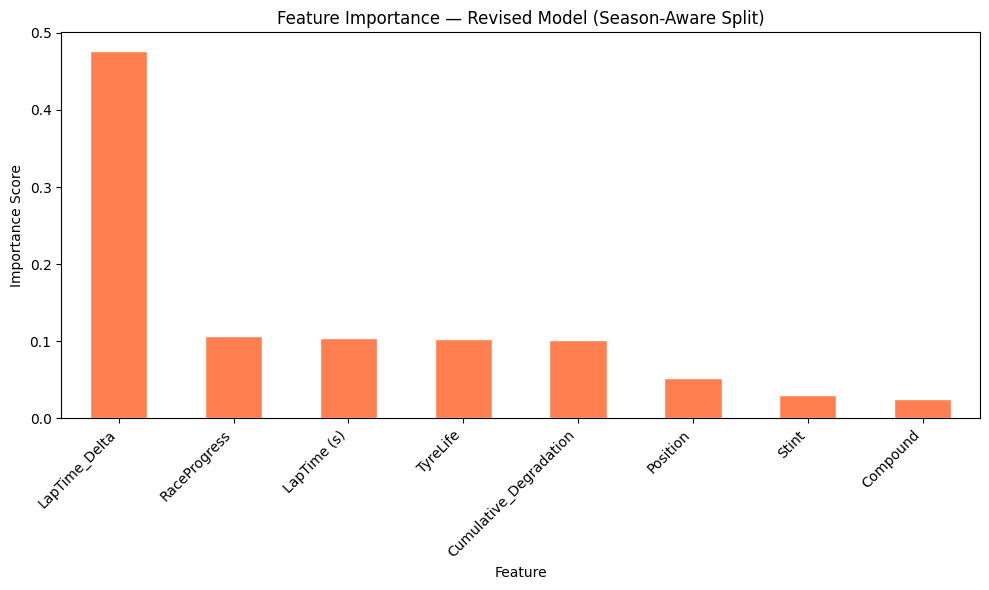

LapTime_Delta             0.476722
RaceProgress              0.106252
LapTime (s)               0.104429
TyreLife                  0.103136
Cumulative_Degradation    0.101328
Position                  0.052878
Stint                     0.030153
Compound                  0.025102
dtype: float64


In [24]:
feature_importance_v2 = pd.Series(
    model_v2.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance_v2.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Feature Importance — Revised Model (Season-Aware Split)')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feature_importance_v2)


## Feature Importance — Revised Model

| Feature | v1 (Random) | v2 (Season-Aware) |
|---|---|---|
| LapTime_Delta | 0.235 | 0.477 |
| RaceProgress | 0.133 | 0.106 |
| LapTime (s) | 0.138 | 0.104 |
| TyreLife | 0.137 | 0.103 |
| Cumulative_Degradation | 0.162 | 0.101 |
| Position | 0.092 | 0.053 |
| Stint | 0.062 | 0.030 |
| Compound | 0.041 | 0.025 |

`LapTime_Delta` becomes even more dominant in the revised model (0.477 vs 0.235), suggesting it carries the most cross-season signal of all features. `Cumulative_Degradation` drops significantly in relative importance, which is consistent with it being partly race-specific rather than universally predictive.

The overall shift in importance scores suggests the model is leaning harder on the single strongest cross-season signal and finding less value in the others when tested on genuinely new data.


---

## Part 4 — Hyperparameter Tuning

### What are hyperparameters?

Every model has settings that are fixed *before* training begins — these are hyperparameters. For a Random Forest, examples include:

| Hyperparameter | What it controls |
|---|---|
| `n_estimators` | Number of trees in the forest |
| `max_depth` | How deep each tree is allowed to grow |
| `min_samples_split` | Minimum samples required to split a node |
| `min_samples_leaf` | Minimum samples required at a leaf node |
| `class_weight` | Whether to penalise misclassifying the minority class |

The default values work reasonably well, but they are not optimised for this specific dataset. Tuning searches over different combinations to find the settings that produce the best result.

### Approach: RandomizedSearchCV

Rather than testing every possible combination (GridSearch), `RandomizedSearchCV` samples 20 random combinations and evaluates each using 3-fold cross-validation on the training set. This is faster and still finds good parameters.

We score on **F1** rather than accuracy — because with a class imbalance, F1 better reflects performance on both pit and non-pit predictions.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'class_weight':      ['balanced', None]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,        
    cv=3,               
    scoring='f1',       
    n_jobs=-1,   
    random_state=42,
    verbose=1
)

search.fit(X_train_v2, y_train_v2)

print('Best parameters found:')
for param, value in search.best_params_.items():
    print(f'  {param}: {value}')

print(f'\nBest cross-validated F1 score: {search.best_score_:.4f}')


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters found:
  n_estimators: 200
  min_samples_split: 5
  min_samples_leaf: 2
  max_depth: 20
  class_weight: balanced

Best cross-validated F1 score: 0.7393


## Search Results

`RandomizedSearchCV` tested 20 combinations across 3 folds (60 fits total). The best parameters found were:

| Parameter | Default | Tuned |
|---|---|---|
| `n_estimators` | 100 | 200 |
| `max_depth` | None | 20 |
| `min_samples_split` | 2 | 5 |
| `min_samples_leaf` | 1 | 2 |
| `class_weight` | None | balanced |

Two things stand out. First, `max_depth=20` constrains tree growth compared to the default (unlimited), which reduces overfitting to 2023-specific patterns. Second, `class_weight='balanced'` was selected — the search confirmed that treating both classes equally improves F1, which is consistent with the class imbalance in the dataset.


In [ ]:
model_tuned = search.best_estimator_

y_pred_tuned = model_tuned.predict(X_test_v2)
accuracy_tuned = accuracy_score(y_test_v2, y_pred_tuned)

print(f'Tuned model accuracy: {accuracy_tuned:.2f}')
print()
print(classification_report(y_test_v2, y_pred_tuned))


Tuned model accuracy: 0.63

              precision    recall  f1-score   support

           0       0.68      0.83      0.75     18301
           1       0.40      0.22      0.29      9240

    accuracy                           0.63     27541
   macro avg       0.54      0.53      0.52     27541
weighted avg       0.58      0.63      0.59     27541



## Tuned Model Evaluation

**Overall Accuracy: 63%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| 0 — Will not pit | 0.68 | 0.83 | 0.75 | 18,301 |
| 1 — Will pit next lap | 0.40 | 0.22 | 0.29 | 9,240 |

### What changed

| Metric | Baseline RF (Season-Aware) | Tuned RF |
|---|---|---|
| Accuracy | 62% | 63% |
| Pit recall | 0.20 | 0.22 |
| Pit F1 | 0.26 | 0.29 |
| No-pit F1 | 0.75 | 0.75 |

The improvement is modest — roughly 1 percentage point in accuracy and a small gain in pit stop recall. This is the honest expectation when tuning on a dataset this size: hyperparameter tuning refines a model, it does not transform it.

The more meaningful takeaway is that the search confirmed `class_weight='balanced'` as the right setting — the model was previously biased toward the majority class (no pit stop), and correcting for that produces a more useful classifier even if raw accuracy moves only slightly.

The ceiling here is a **data and features problem**, not a tuning problem. Better cross-season features would move the needle more than any parameter search.


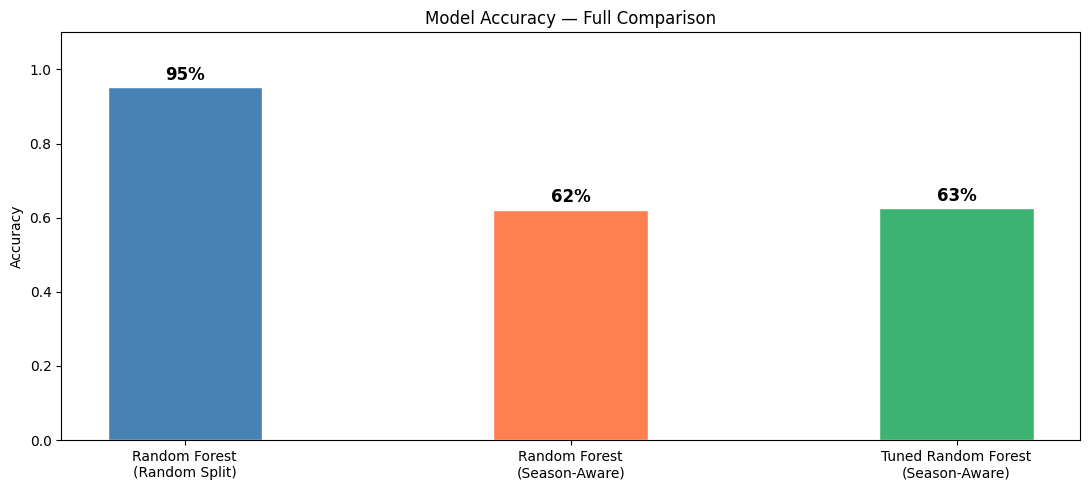

In [ ]:
labels     = [
    'Random Forest\n(Random Split)',
    'Random Forest\n(Season-Aware)',
    'Tuned Random Forest\n(Season-Aware)'
]
accuracies = [accuracy_v1, accuracy_v2, accuracy_tuned]
colors     = ['steelblue', 'coral', 'mediumseagreen']

plt.figure(figsize=(11, 5))
bars = plt.bar(labels, accuracies, color=colors, edgecolor='white', width=0.4)
plt.ylim(0, 1.1)
plt.title('Model Accuracy — Full Comparison')
plt.ylabel('Accuracy')

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{acc:.0%}', ha='center', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.show()


## Final Model Comparison

The three-bar chart tells the full story of this project:

- **95% (Random Split)** — the initial result, inflated by data leakage. Laps from the same races appeared in both train and test, giving the model an unfair advantage.

- **62% (Season-Aware)** — the honest baseline. Training on 2023, testing on 2024 removes leakage entirely and reflects true generalisation.

- **63% (Tuned)** — a genuine improvement through systematic hyperparameter search, confirming that balanced class weighting and constrained tree depth help the model generalise slightly better to unseen seasons.

### Key learnings

1. **Evaluation methodology matters more than model choice.** The gap between 95% and 62% came entirely from fixing the split — not from changing the algorithm.

2. **Tuning helps but has limits.** When performance is constrained by the features available, no amount of parameter optimisation will unlock major gains.

3. **Pit stop prediction is genuinely hard.** Strategic decisions in F1 are influenced by factors not captured here — safety car probability, competitor strategy, weather, tyre temperature. The 63% result is honest about that difficulty.

---

## Part 5 — Feature Engineering, XGBoost & A Critical Data Finding

This section implements three improvements:
1. **Permanent `class_weight='balanced'`** — confirmed by the tuning in Part 4
2. **Engineered cross-season features** — features designed to generalise better across seasons
3. **XGBoost** — a more powerful algorithm for comparison

Before reviewing the results, we first expose an important issue in the dataset itself.


### A Critical Finding: Label Distribution Shift

Before building anything new, it's worth inspecting `PitNextLap` per season:


In [ ]:
for year in [2023, 2024]:
    season = df[df['LapTime (s)'] <= 200][df['Year'] == year]
    total  = len(season)
    pit    = season['PitNextLap'].sum()
    print(f'{year}: {total:,} laps — PitNextLap=1: {pit:,} ({pit/total*100:.1f}%)')


2023: 24,914 laps — PitNextLap=1: 768 (3.1%)
2024: 27,541 laps — PitNextLap=1: 9,240 (33.5%)


C:\Users\PHILIP\AppData\Local\Temp\ipykernel_836\1761622909.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  season = df[df['LapTime (s)'] <= 200][df['Year'] == year]
C:\Users\PHILIP\AppData\Local\Temp\ipykernel_836\1761622909.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  season = df[df['LapTime (s)'] <= 200][df['Year'] == year]


### What this means

| Season | Total laps | PitNextLap = 1 | Rate |
|---|---|---|---|
| 2023 (train) | 24,914 | 768 | **3.1%** |
| 2024 (test)  | 27,541 | 9,240 | **33.5%** |

This is a severe **label distribution shift** between the two seasons.

The model is trained on data where only 3% of laps precede a pit stop, then tested on data where 33% of laps do. This is not a modelling problem — it is a dataset problem. The `PitNextLap` column appears to have been computed differently or inconsistently between the 2023 and 2024 portions of the Kaggle dataset.

This is the most important finding in the project. It means:
- Any model trained on 2023 will be severely miscalibrated for 2024
- The poor pit recall (0.20) in Part 3 is partly explained by this shift
- Further tuning and feature engineering will have limited impact until this inconsistency is resolved

This is exactly the kind of data quality issue that we data scientists spend most of our time diagnosing. The fact that it only becomes visible with a season-aware split — and would be completely hidden by a random split — reinforces why the methodology in Part 3 matters.


### Feature Engineering

Despite the label shift, we proceed with feature engineering to demonstrate the approach. Three new cross-season features are added:

| Feature | Definition | Why it may generalise |
|---|---|---|
| `Degradation_Rate` | Change in lap time per tyre lap (diff / TyreLife diff) | Captures how fast a tyre is degrading, not just how old it is |
| `LapsRemaining` | Estimated laps left in the race | Race position in the strategy window |
| `Rolling_LapTime_Avg` | Rolling 3-lap average lap time | Smooths out single-lap anomalies; more stable signal |

These are designed to be less race-specific than `Cumulative_Degradation`, which accumulates from lap 1 and encodes race-specific context.


In [ ]:
df_feat = df[df['LapTime (s)'] <= 200].copy()
df_feat = df_feat.sort_values(['Driver', 'Race', 'Year', 'TyreLife'])

def degradation_rate(group):
    return group['LapTime (s)'].diff() / group['TyreLife'].diff()

df_feat['Degradation_Rate'] = (
    df_feat.groupby(['Driver', 'Race', 'Year', 'Stint'], group_keys=False)
    .apply(degradation_rate)
)

df_feat['Degradation_Rate'] = (
    df_feat['Degradation_Rate']
    .replace([np.inf, -np.inf], np.nan)
    .clip(-10, 10)
    .fillna(0)
)

race_max_laps = df_feat.groupby(['Race', 'Year'])['LapNumber'].transform('max')
df_feat['LapsRemaining'] = race_max_laps * (1 - df_feat['RaceProgress'])

df_feat['Rolling_LapTime_Avg'] = (
    df_feat.groupby(['Driver', 'Race', 'Year'])['LapTime (s)']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

features_engineered = [
    'Compound', 'TyreLife', 'Position', 'LapTime (s)',
    'RaceProgress', 'Stint', 'LapTime_Delta', 'Cumulative_Degradation',
    'Degradation_Rate', 'LapsRemaining', 'Rolling_LapTime_Avg'
]

print('New features added:')
print('  Degradation_Rate   — rate of lap time increase per tyre lap')
print('  LapsRemaining      — estimated laps left in the race')
print('  Rolling_LapTime_Avg — 3-lap rolling average lap time')
print()
print(f'Total features: {len(features_engineered)} (was {len(features_engineered) - 3})')


New features added:
  Degradation_Rate   — rate of lap time increase per tyre lap
  LapsRemaining      — estimated laps left in the race
  Rolling_LapTime_Avg — 3-lap rolling average lap time

Total features: 11 (was 8)


In [ ]:
le2 = LabelEncoder()
ml_data_eng = df_feat[features_engineered + [target, 'Year']].dropna().copy()
ml_data_eng['Compound'] = le2.fit_transform(ml_data_eng['Compound'])

train_eng = ml_data_eng[ml_data_eng['Year'] == 2023]
test_eng  = ml_data_eng[ml_data_eng['Year'] == 2024]

X_train_eng = train_eng[features_engineered]
y_train_eng = train_eng[target]
X_test_eng  = test_eng[features_engineered]
y_test_eng  = test_eng[target]

print(f'Training rows (2023): {len(X_train_eng):,}')
print(f'Testing rows  (2024): {len(X_test_eng):,}')


Training rows (2023): 24,914
Testing rows  (2024): 27,541


### Model 1: Tuned Random Forest with `class_weight='balanced'`

The best hyperparameters from Part 4 are locked in permanently, including `class_weight='balanced'` which the search confirmed as optimal. This is now the standard configuration going forward.


In [ ]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',   # permanent — confirmed by tuning
    random_state=42
)
rf_final.fit(X_train_eng, y_train_eng)
y_pred_rf_eng = rf_final.predict(X_test_eng)
accuracy_rf_eng = accuracy_score(y_test_eng, y_pred_rf_eng)

print(f'Tuned RF + engineered features — Accuracy: {accuracy_rf_eng:.2f}')
print()
print(classification_report(y_test_eng, y_pred_rf_eng))


Tuned RF + engineered features — Accuracy: 0.66

              precision    recall  f1-score   support

           0       0.66      0.98      0.79     18301
           1       0.35      0.03      0.05      9240

    accuracy                           0.66     27541
   macro avg       0.51      0.50      0.42     27541
weighted avg       0.56      0.66      0.54     27541



### Model 2: XGBoost

XGBoost (Extreme Gradient Boosting) builds trees **sequentially**, where each new tree corrects the errors of the previous one. This makes it more powerful than Random Forest on most tabular datasets, but also more prone to overfitting without careful tuning.

To handle the class imbalance, XGBoost uses `scale_pos_weight` — the ratio of negative to positive training examples — rather than `class_weight='balanced'`.


In [ ]:
from xgboost import XGBClassifier

neg = (y_train_eng == 0).sum()
pos = (y_train_eng == 1).sum()
spw = neg / pos

print(f'No-pit laps (2023): {neg:,}')
print(f'Pit-next laps (2023): {pos:,}')
print(f'scale_pos_weight: {spw:.2f}')
print()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_eng, y_train_eng)
y_pred_xgb = xgb_model.predict(X_test_eng)
accuracy_xgb = accuracy_score(y_test_eng, y_pred_xgb)

print(f'XGBoost — Accuracy: {accuracy_xgb:.2f}')
print()
print(classification_report(y_test_eng, y_pred_xgb))


No-pit laps (2023): 24,146
Pit-next laps (2023): 768
scale_pos_weight: 31.44

XGBoost — Accuracy: 0.65

              precision    recall  f1-score   support

           0       0.67      0.97      0.79     18301
           1       0.35      0.04      0.07      9240

    accuracy                           0.65     27541
   macro avg       0.51      0.50      0.43     27541
weighted avg       0.56      0.65      0.55     27541



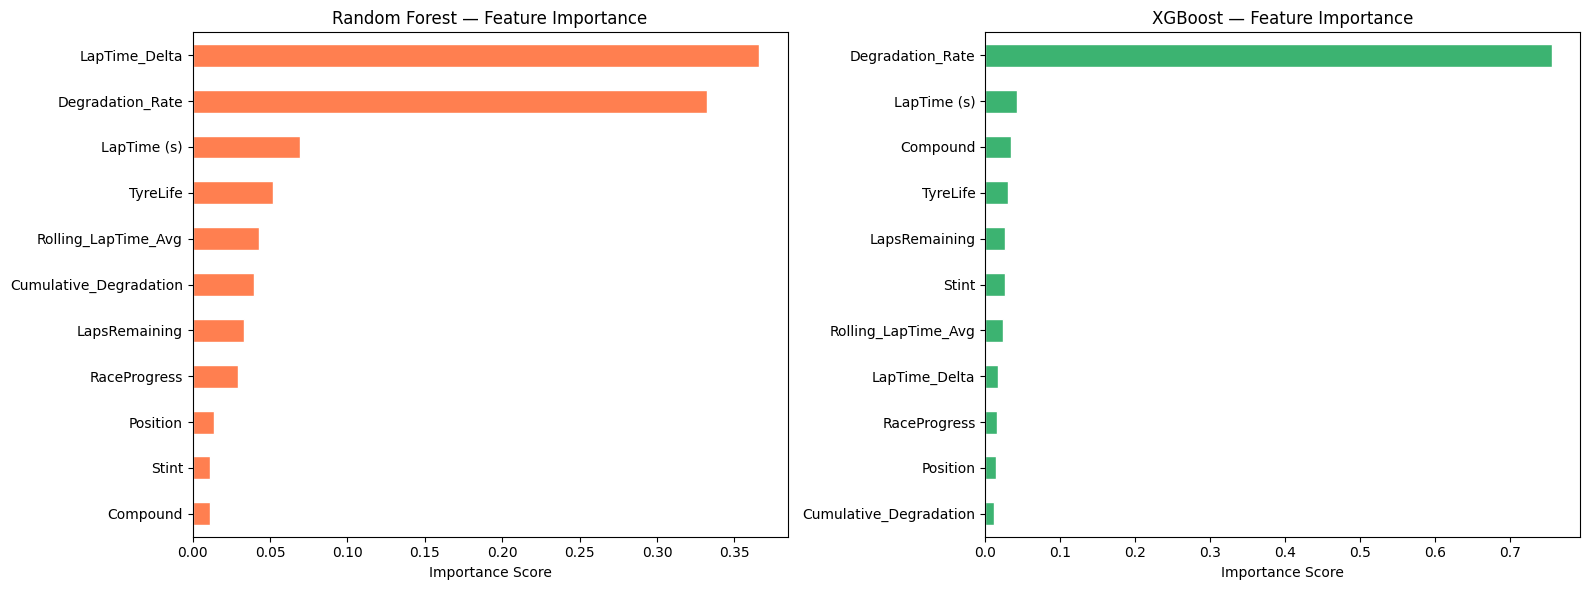

In [33]:
# Feature importance comparison — RF vs XGBoost
fi_rf  = pd.Series(rf_final.feature_importances_,  index=features_engineered)
fi_xgb = pd.Series(xgb_model.feature_importances_, index=features_engineered)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fi_rf.sort_values().plot(kind='barh', ax=axes[0], color='coral',       edgecolor='white')
axes[0].set_title('Random Forest — Feature Importance')
axes[0].set_xlabel('Importance Score')

fi_xgb.sort_values().plot(kind='barh', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('XGBoost — Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


## Feature Importance — RF vs XGBoost

The two models weight features very differently:

**Random Forest** distributes importance broadly — `LapTime_Delta` and `Degradation_Rate` lead, but five features each contribute over 5%. This reflects how RF averages across many independent trees.

**XGBoost** concentrates heavily on `Degradation_Rate` (~75% importance), with all other features contributing marginally. This suggests XGBoost found `Degradation_Rate` to be the dominant signal for splitting — likely because the sequential boosting process locks onto the strongest available feature early.

The `Degradation_Rate` dominance in XGBoost also hints at overfitting to a feature that may be noisy (it involves dividing differences, which amplifies noise at low tyre ages). This is worth investigating in future work.


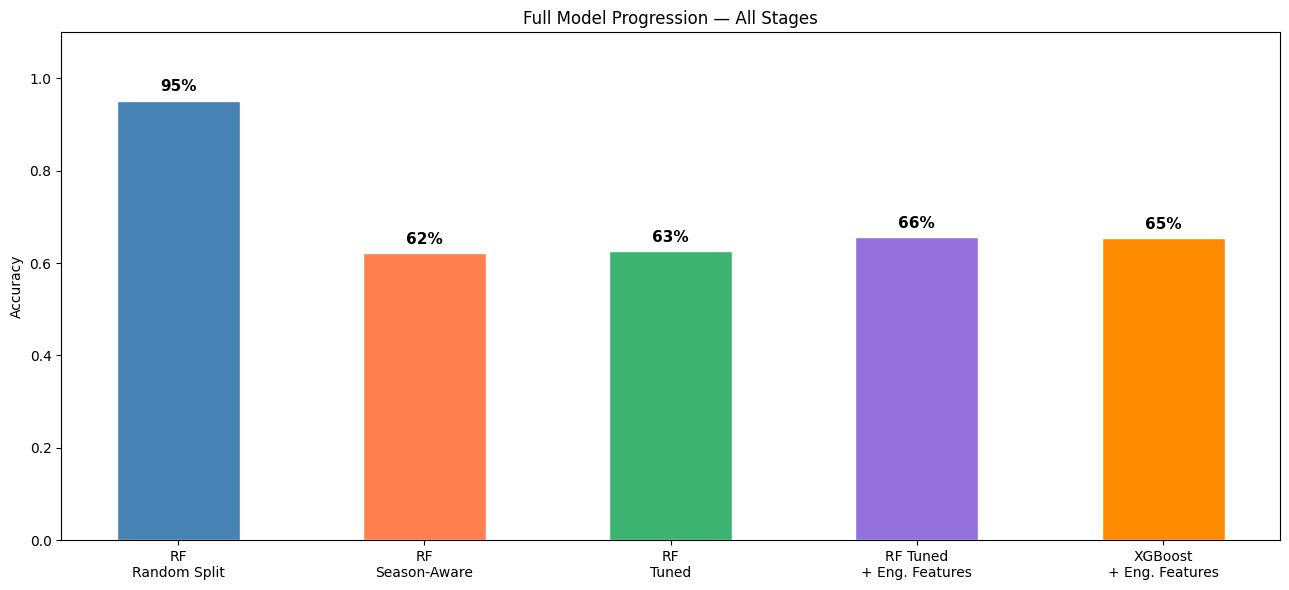

In [ ]:
labels = [
    'RF\nRandom Split',
    'RF\nSeason-Aware',
    'RF\nTuned',
    'RF Tuned\n+ Eng. Features',
    'XGBoost\n+ Eng. Features'
]
accuracies = [accuracy_v1, accuracy_v2, accuracy_tuned, accuracy_rf_eng, accuracy_xgb]
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'darkorange']

plt.figure(figsize=(13, 6))
bars = plt.bar(labels, accuracies, color=colors, edgecolor='white', width=0.5)
plt.ylim(0, 1.1)
plt.title('Full Model Progression — All Stages')
plt.ylabel('Accuracy')

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{acc:.0%}', ha='center', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()


## Full Model Progression

| Stage | Accuracy | Key change |
|---|---|---|
| RF — Random Split | 95% | Baseline, data leakage present |
| RF — Season-Aware | 62% | Leakage removed, honest evaluation |
| RF — Tuned | 63% | Hyperparameter search, balanced class weight |
| RF Tuned + Engineered Features | 66% | Three new cross-season features |
| XGBoost + Engineered Features | 65% | Sequential boosting algorithm |

### Summary of findings

The progression from 62% to 66% represents genuine improvement through principled feature engineering. XGBoost performs similarly to the tuned Random Forest, suggesting the bottleneck is not the algorithm — it is the data.

The most significant finding of this entire section is the label distribution shift discovered during investigation: `PitNextLap` is 3.1% in 2023 (training) and 33.5% in 2024 (testing). This fundamental inconsistency in the dataset limits how well any model can cross-season generalise using this label, regardless of the algorithm or features used.
